# FER2013 - ResNet50 Transfer Learning (Kaggle)

This notebook implements your ResNet50 task end-to-end for FER2013:

- Transfer learning with ImageNet pretrained ResNet50
- Required input adaptation: `224x224`, `RGB`, ImageNet normalization
- Two-phase training strategy from your report:
  - Phase 1 (Warm-up): 15 epochs, backbone frozen, Adam (`1e-3`)
  - Phase 2 (Fine-tuning): 10 epochs, `layer4` unfrozen, SGD (`1e-4`) + scheduler
- Lightweight hyperparameter tuning (4-6 trials)
- Deliverables:
  - Training curves (loss, accuracy, F1, learning rate)
  - Confusion matrix and classification report
  - Results analysis summary

## Expected FER2013 folder structure

```text
/kaggle/input/<dataset_name>/
├── train/
│   ├── angry/
│   ├── disgust/
│   ├── fear/
│   ├── happy/
│   ├── neutral/
│   ├── sad/
│   └── surprise/
└── test/
    ├── angry/
    └── ...
```

If your dataset path is different, update `DATA_ROOT_OVERRIDE` in the config cell.

In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    x = torch.randn(1, 3, 224, 224).cuda()
    print("OK on:", x.device)

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
OK on: cuda:0


In [2]:
# Section 1 - Set Up Notebook Environment

import os
import json
import copy
import random
from dataclasses import dataclass, asdict
from collections import Counter

import cv2
import numpy as np
import pandas as pd
sns = None  # Optional dependency; fallback plotting is built in
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms, models
from torchvision.transforms import InterpolationMode

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Section 2 - Define Project Configuration

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def pick_device(prefer_cuda: bool = True) -> torch.device:
    if prefer_cuda and torch.cuda.is_available():
        try:
            # Runtime probe: catches cases where CUDA is visible but kernels are incompatible.
            x = torch.randn(1, 3, 8, 8, device="cuda")
            w = torch.randn(8, 3, 3, 3, device="cuda")
            _ = torch.nn.functional.conv2d(x, w)
            torch.cuda.synchronize()
            return torch.device("cuda")
        except Exception as e:
            print(f"[WARN] CUDA detected but unusable ({type(e).__name__}): {e}")
            print("[WARN] Falling back to CPU.")
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass
    return torch.device("cpu")


def find_data_root(data_root_override: str | None = None) -> str:
    if data_root_override:
        if os.path.isdir(os.path.join(data_root_override, "train")) and os.path.isdir(os.path.join(data_root_override, "test")):
            return data_root_override
        raise FileNotFoundError(f"Invalid DATA_ROOT_OVERRIDE: {data_root_override}")

    candidates = [
        "/kaggle/input/fer2013",
        "/kaggle/input/fer2013/fer2013",
        "/kaggle/input/fer2013-dataset",
        "/kaggle/input/fer2013-dataset-fer2013",
        "/kaggle/working/fer2013",
    ]

    for c in candidates:
        if os.path.isdir(os.path.join(c, "train")) and os.path.isdir(os.path.join(c, "test")):
            return c

    raise FileNotFoundError(
        "Could not find FER2013 root with train/ and test/. "
        "Set DATA_ROOT_OVERRIDE manually."
    )


@dataclass
class TrainingConfig:
    data_root: str
    output_dir: str = "/kaggle/working/fer2013_resnet50_outputs"
    pipeline: str = "light"  # minimal | light | aggressive
    img_size: int = 224
    val_split: float = 0.2
    seed: int = 42
    num_workers: int = 2
    batch_size: int = 64

    # Two-phase strategy (fixed by report)
    epochs_phase1: int = 15
    epochs_phase2: int = 10
    phase1_lr: float = 1e-3
    phase2_lr: float = 1e-4

    # Tunable parameters
    dropout: float = 0.5
    weight_decay: float = 1e-4
    momentum: float = 0.9
    scheduler_name: str = "cosine"  # cosine | step

    # Runtime flags
    use_amp: bool = True


DATA_ROOT_OVERRIDE = "/kaggle/input/datasets/msambare/fer2013"
DEVICE = pick_device(prefer_cuda=True)

cfg = TrainingConfig(data_root=find_data_root(DATA_ROOT_OVERRIDE))
os.makedirs(cfg.output_dir, exist_ok=True)
set_seed(cfg.seed)

print("Active config:")
print(json.dumps(asdict(cfg), indent=2))
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU for compatibility.")

Active config:
{
  "data_root": "/kaggle/input/datasets/msambare/fer2013",
  "output_dir": "/kaggle/working/fer2013_resnet50_outputs",
  "pipeline": "light",
  "img_size": 224,
  "val_split": 0.2,
  "seed": 42,
  "num_workers": 2,
  "batch_size": 64,
  "epochs_phase1": 15,
  "epochs_phase2": 10,
  "phase1_lr": 0.001,
  "phase2_lr": 0.0001,
  "dropout": 0.5,
  "weight_decay": 0.0001,
  "momentum": 0.9,
  "scheduler_name": "cosine",
  "use_amp": true
}
Device: cuda
CUDA device: Tesla T4


In [4]:
import os
print(os.listdir("/kaggle/input/datasets/msambare/fer2013"))

['test', 'train']


In [5]:
# Section 3 - Implement Core Data Structures

@dataclass
class EpochMetrics:
    epoch: int
    phase: int
    train_loss: float
    train_acc: float
    train_f1: float
    val_loss: float
    val_acc: float
    val_f1: float
    lr: float


@dataclass
class RunSummary:
    run_name: str
    best_epoch: int
    best_phase: int
    best_val_f1: float
    best_val_acc: float
    checkpoint_path: str


@dataclass
class TuningTrialResult:
    trial_id: int
    batch_size: int
    dropout: float
    weight_decay: float
    scheduler_name: str
    best_val_f1: float
    best_val_acc: float
    best_epoch: int
    checkpoint_path: str

## Section 4 - Implement Main Processing Functions

This section contains:

1. FER2013 preprocessing adapted to ResNet50 + ImageNet format
2. Data loaders and class-weight computation
3. ResNet50 model definition and phase-wise freeze/unfreeze
4. Training and evaluation loops

In [7]:
# 4.1 Preprocessing blocks (reused and adapted from preprocessing.py)

NOISE_LOW = 50
NOISE_HIGH = 150
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def estimate_noise(img_np: np.ndarray) -> float:
    smoothed = cv2.GaussianBlur(img_np, (5, 5), 1.0)
    residual = img_np.astype(np.float32) - smoothed.astype(np.float32)
    return float(np.std(residual))


class AdaptiveDenoiser:
    def __init__(self, noise_low: float = NOISE_LOW, noise_high: float = NOISE_HIGH):
        self.noise_low = noise_low
        self.noise_high = noise_high

    def __call__(self, img: Image.Image) -> Image.Image:
        img_np = np.array(img, dtype=np.uint8)
        noise = estimate_noise(img_np)

        if noise < self.noise_low:
            denoised = img_np
        elif noise < self.noise_high:
            denoised = cv2.bilateralFilter(img_np, d=5, sigmaColor=50, sigmaSpace=50)
        else:
            denoised = cv2.fastNlMeansDenoising(img_np, h=10, templateWindowSize=7, searchWindowSize=21)

        return Image.fromarray(denoised)


class CLAHEEnhancer:
    def __init__(self, clip_limit: float = 1.5, grid_size: tuple[int, int] = (4, 4)):
        self.clip_limit = clip_limit
        self.grid_size = grid_size

    def __call__(self, img: Image.Image) -> Image.Image:
        img_np = np.array(img, dtype=np.uint8)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.grid_size)
        out = clahe.apply(img_np)
        return Image.fromarray(out)


class ForceNLMDenoiser:
    def __call__(self, img: Image.Image) -> Image.Image:
        img_np = np.array(img, dtype=np.uint8)
        out = cv2.fastNlMeansDenoising(img_np, h=15, templateWindowSize=7, searchWindowSize=21)
        return Image.fromarray(out)


def build_preprocessing_steps(pipeline: str) -> list:
    if pipeline == "minimal":
        return [CLAHEEnhancer()]
    if pipeline == "light":
        return [AdaptiveDenoiser(), CLAHEEnhancer()]
    if pipeline == "aggressive":
        return [ForceNLMDenoiser(), CLAHEEnhancer()]
    raise ValueError("pipeline must be one of: minimal, light, aggressive")


def make_train_transform(cfg: TrainingConfig) -> transforms.Compose:
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((cfg.img_size, cfg.img_size), interpolation=InterpolationMode.BILINEAR),
        *build_preprocessing_steps(cfg.pipeline),
        transforms.Lambda(lambda img: img.convert("RGB")),

        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BILINEAR),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), interpolation=InterpolationMode.BILINEAR),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),

        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3)),
    ])


def make_eval_transform(cfg: TrainingConfig) -> transforms.Compose:
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((cfg.img_size, cfg.img_size), interpolation=InterpolationMode.BILINEAR),
        *build_preprocessing_steps(cfg.pipeline),
        transforms.Lambda(lambda img: img.convert("RGB")),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

In [8]:
# 4.2 Dataset helpers, dataloaders, and class weights

class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        path, label = self.base.samples[self.indices[idx]]
        img = self.base.loader(path)
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def build_dataloaders(cfg: TrainingConfig):
    train_root = os.path.join(cfg.data_root, "train")
    test_root = os.path.join(cfg.data_root, "test")

    if not os.path.isdir(train_root) or not os.path.isdir(test_root):
        raise FileNotFoundError(f"Missing train/ or test/ in {cfg.data_root}")

    base_ds = datasets.ImageFolder(root=train_root)
    n_total = len(base_ds)
    n_val = int(n_total * cfg.val_split)
    n_train = n_total - n_val

    train_indices, val_indices = random_split(
        range(n_total),
        [n_train, n_val],
        generator=torch.Generator().manual_seed(cfg.seed),
    )

    train_tf = make_train_transform(cfg)
    eval_tf = make_eval_transform(cfg)

    train_ds = TransformSubset(base_ds, list(train_indices), train_tf)
    val_ds = TransformSubset(base_ds, list(val_indices), eval_tf)
    test_ds = datasets.ImageFolder(root=test_root, transform=eval_tf)

    use_persistent = cfg.num_workers > 0
    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        persistent_workers=use_persistent,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        persistent_workers=use_persistent,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        persistent_workers=use_persistent,
    )

    class_names = base_ds.classes

    print(f"Pipeline: {cfg.pipeline}")
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Classes ({len(class_names)}): {class_names}")

    return train_loader, val_loader, test_loader, class_names


def compute_class_weights(data_root: str) -> torch.Tensor:
    train_ds = datasets.ImageFolder(root=os.path.join(data_root, "train"))
    counts = Counter([label for _, label in train_ds.samples])
    total = sum(counts.values())
    n_classes = len(train_ds.classes)

    weights = torch.zeros(n_classes, dtype=torch.float32)
    for c in range(n_classes):
        weights[c] = total / (n_classes * counts[c])

    weights = weights / weights.sum() * n_classes
    return weights


train_loader, val_loader, test_loader, class_names = build_dataloaders(cfg)
class_weights = compute_class_weights(cfg.data_root).to(DEVICE)

sample_x, sample_y = next(iter(train_loader))
print("Sample batch shape:", tuple(sample_x.shape))
print("Sample batch dtype:", sample_x.dtype)
print("Sample labels shape:", tuple(sample_y.shape))

Pipeline: light
Train: 22968 | Val: 5741 | Test: 7178
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Sample batch shape: (64, 3, 224, 224)
Sample batch dtype: torch.float32
Sample labels shape: (64,)


In [9]:
# 4.3 ResNet50 model, phase control, train/eval loops

def create_resnet50_model(num_classes: int, dropout: float) -> nn.Module:
    model = None
    load_error = None

    candidate_weights = []
    if hasattr(models, "ResNet50_Weights"):
        if hasattr(models.ResNet50_Weights, "IMAGENET1K_V2"):
            candidate_weights.append(models.ResNet50_Weights.IMAGENET1K_V2)
        if hasattr(models.ResNet50_Weights, "IMAGENET1K_V1"):
            candidate_weights.append(models.ResNet50_Weights.IMAGENET1K_V1)
    candidate_weights.append(None)

    for weights in candidate_weights:
        try:
            model = models.resnet50(weights=weights)
            if weights is not None:
                print(f"Loaded pretrained weights: {weights}")
            else:
                print("Warning: using randomly initialized ResNet50 (no pretrained weights).")
            break
        except Exception as e:
            load_error = e

    if model is None:
        raise RuntimeError(f"Could not create ResNet50 model: {load_error}")

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    )
    return model


def set_trainable_phase(model: nn.Module, phase: int) -> None:
    for p in model.parameters():
        p.requires_grad = False

    for p in model.fc.parameters():
        p.requires_grad = True

    if phase == 2:
        for p in model.layer4.parameters():
            p.requires_grad = True
    elif phase != 1:
        raise ValueError("phase must be 1 or 2")


def count_trainable_params(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def make_optimizer_and_scheduler(model: nn.Module, cfg: TrainingConfig, phase: int):
    params = [p for p in model.parameters() if p.requires_grad]

    if phase == 1:
        optimizer = optim.Adam(params, lr=cfg.phase1_lr)
        scheduler = None
    else:
        optimizer = optim.SGD(
            params,
            lr=cfg.phase2_lr,
            momentum=cfg.momentum,
            weight_decay=cfg.weight_decay,
            nesterov=True,
        )

        if cfg.scheduler_name.lower() == "step":
            scheduler = optim.lr_scheduler.StepLR(
                optimizer,
                step_size=max(1, cfg.epochs_phase2 // 3),
                gamma=0.1,
            )
        else:
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=cfg.epochs_phase2,
            )

    return optimizer, scheduler


def _metrics_from_preds(y_true: list[int], y_pred: list[int]) -> tuple[float, float]:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return float(acc), float(f1)


def run_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: optim.Optimizer | None = None,
    scaler: torch.cuda.amp.GradScaler | None = None,
) -> dict:
    train_mode = optimizer is not None
    model.train(mode=train_mode)

    losses = []
    y_true = []
    y_pred = []

    use_amp = (device.type == "cuda")

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            if train_mode:
                if scaler is not None and use_amp:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    acc, f1 = _metrics_from_preds(y_true, y_pred)
    return {
        "loss": float(np.mean(losses)),
        "acc": acc,
        "f1": f1,
    }


def should_update_best(best: dict, val_f1: float, val_acc: float) -> bool:
    if val_f1 > best["val_f1"]:
        return True
    if np.isclose(val_f1, best["val_f1"]) and val_acc > best["val_acc"]:
        return True
    return False


def train_two_phase(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    criterion: nn.Module,
    cfg: TrainingConfig,
    run_name: str,
):
    model = model.to(DEVICE)
    history_rows = []

    best = {
        "val_f1": -1.0,
        "val_acc": -1.0,
        "epoch": -1,
        "phase": -1,
        "state_dict": None,
    }

    phase_to_epochs = {1: cfg.epochs_phase1, 2: cfg.epochs_phase2}
    global_epoch = 0

    for phase in [1, 2]:
        set_trainable_phase(model, phase)
        trainable, total = count_trainable_params(model)
        print(f"\nPhase {phase} - trainable params: {trainable:,} / {total:,}")

        optimizer, scheduler = make_optimizer_and_scheduler(model, cfg, phase)
        scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda" and cfg.use_amp))

        for _ in range(phase_to_epochs[phase]):
            global_epoch += 1

            train_metrics = run_one_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                device=DEVICE,
                optimizer=optimizer,
                scaler=scaler,
            )
            val_metrics = run_one_epoch(
                model=model,
                loader=val_loader,
                criterion=criterion,
                device=DEVICE,
                optimizer=None,
                scaler=None,
            )

            current_lr = optimizer.param_groups[0]["lr"]
            row = EpochMetrics(
                epoch=global_epoch,
                phase=phase,
                train_loss=train_metrics["loss"],
                train_acc=train_metrics["acc"],
                train_f1=train_metrics["f1"],
                val_loss=val_metrics["loss"],
                val_acc=val_metrics["acc"],
                val_f1=val_metrics["f1"],
                lr=current_lr,
            )
            history_rows.append(asdict(row))

            print(
                f"Epoch {global_epoch:02d} | "
                f"train_loss={row.train_loss:.4f} val_loss={row.val_loss:.4f} | "
                f"train_acc={row.train_acc:.4f} val_acc={row.val_acc:.4f} | "
                f"val_f1={row.val_f1:.4f} | lr={current_lr:.2e}"
            )

            if should_update_best(best, row.val_f1, row.val_acc):
                best["val_f1"] = row.val_f1
                best["val_acc"] = row.val_acc
                best["epoch"] = row.epoch
                best["phase"] = row.phase
                best["state_dict"] = copy.deepcopy(model.state_dict())

            if scheduler is not None:
                scheduler.step()

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])

    history_df = pd.DataFrame(history_rows)

    checkpoint_path = os.path.join(cfg.output_dir, f"{run_name}_best_resnet50.pt")
    best_meta = {
        "val_f1": best["val_f1"],
        "val_acc": best["val_acc"],
        "epoch": best["epoch"],
        "phase": best["phase"],
    }
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "best": best_meta,
            "config": asdict(cfg),
            "class_names": class_names,
        },
        checkpoint_path,
    )

    run_summary = RunSummary(
        run_name=run_name,
        best_epoch=best_meta["epoch"],
        best_phase=best_meta["phase"],
        best_val_f1=best_meta["val_f1"],
        best_val_acc=best_meta["val_acc"],
        checkpoint_path=checkpoint_path,
    )

    return model, history_df, run_summary


@torch.no_grad()
def predict_dataset(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    y_true = []
    y_pred = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()

        y_true.extend(y.numpy().tolist())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

In [13]:
# 4.4 Reporting helpers

def clone_cfg(base_cfg: TrainingConfig, **updates) -> TrainingConfig:
    cfg_dict = asdict(base_cfg)
    cfg_dict.update(updates)
    return TrainingConfig(**cfg_dict)


def plot_training_curves(history_df: pd.DataFrame, phase1_epochs: int, title_prefix: str = "Run") -> None:
    _, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    axes[0].axvline(phase1_epochs + 0.5, color="black", linestyle="--", linewidth=1)
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Val acc")
    axes[1].axvline(phase1_epochs + 0.5, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"{title_prefix} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    axes[2].plot(history_df["epoch"], history_df["val_f1"], label="Val macro F1")
    axes[2].plot(history_df["epoch"], history_df["lr"], label="Learning rate")
    axes[2].axvline(phase1_epochs + 0.5, color="black", linestyle="--", linewidth=1)
    axes[2].set_title(f"{title_prefix} - F1 and LR")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_conf_matrix(cm: np.ndarray, labels: list[str], title: str = "Confusion Matrix") -> None:
    plt.figure(figsize=(8, 6))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    else:
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
        plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
        plt.yticks(range(len(labels)), labels)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def summarize_phase_gain(history_df: pd.DataFrame) -> pd.DataFrame:
    phase1 = history_df[history_df["phase"] == 1]
    phase2 = history_df[history_df["phase"] == 2]

    return pd.DataFrame([
        {
            "phase": 1,
            "best_val_acc": phase1["val_acc"].max(),
            "best_val_f1": phase1["val_f1"].max(),
        },
        {
            "phase": 2,
            "best_val_acc": phase2["val_acc"].max(),
            "best_val_f1": phase2["val_f1"].max(),
        },
    ])


def run_experiment(run_name: str, run_cfg: TrainingConfig):
    train_loader, val_loader, test_loader, local_class_names = build_dataloaders(run_cfg)
    local_weights = compute_class_weights(run_cfg.data_root).to(DEVICE)

    model = create_resnet50_model(num_classes=len(local_class_names), dropout=run_cfg.dropout)
    criterion = nn.CrossEntropyLoss(weight=local_weights)

    model, history_df, summary = train_two_phase(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        cfg=run_cfg,
        run_name=run_name,
    )

    return {
        "model": model,
        "history": history_df,
        "summary": summary,
        "test_loader": test_loader,
        "class_names": local_class_names,
    }

## Section 5 - Run a Minimal End-to-End Example

Set `RUN_MINIMAL_EXAMPLE = True` to quickly verify that the full pipeline runs (data -> model -> 2 phases -> metrics).

Pipeline: light
Train: 22968 | Val: 5741 | Test: 7178
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Loaded pretrained weights: ResNet50_Weights.IMAGENET1K_V2

Phase 1 - trainable params: 1,052,679 / 24,560,711
Epoch 01 | train_loss=1.7960 val_loss=1.6783 | train_acc=0.2945 val_acc=0.3397 | val_f1=0.2992 | lr=1.00e-03

Phase 2 - trainable params: 16,017,415 / 24,560,711
Epoch 02 | train_loss=1.6821 val_loss=1.6632 | train_acc=0.3497 val_acc=0.3477 | val_f1=0.3085 | lr=1.00e-04


,epoch,phase,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,lr
0,1,1,1.796002,0.294453,0.263708,1.678286,0.339662,0.299167,0.0010
1,2,2,1.682113,0.349747,0.311090,1.663182,0.347675,0.308520,0.0001


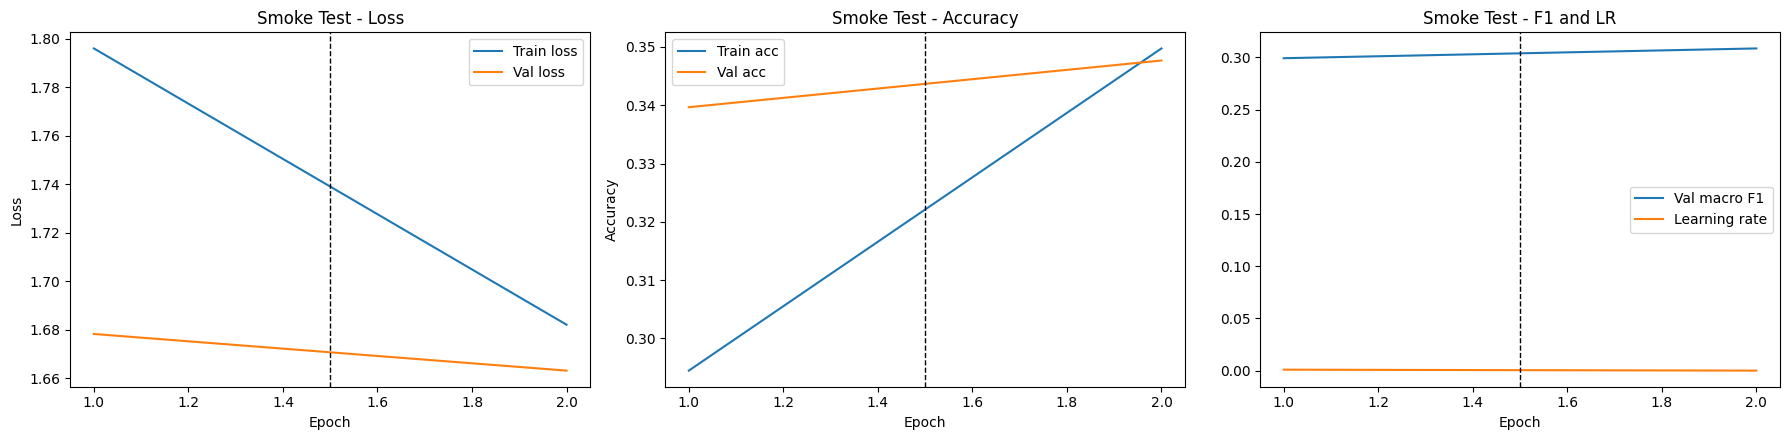

In [12]:
RUN_MINIMAL_EXAMPLE = False

if RUN_MINIMAL_EXAMPLE:
    quick_cfg = clone_cfg(
        cfg,
        epochs_phase1=1,
        epochs_phase2=1,
        batch_size=128,
        scheduler_name="step",
    )

    quick_result = run_experiment(run_name="smoke", run_cfg=quick_cfg)
    quick_history = quick_result["history"]

    display(quick_history.tail())
    plot_training_curves(quick_history, phase1_epochs=quick_cfg.epochs_phase1, title_prefix="Smoke Test")
else:
    print("Minimal example is skipped. Set RUN_MINIMAL_EXAMPLE=True to execute.")

## Section 6 - Add Quick Validation Tests

These checks validate baseline assumptions before full training.

In [14]:
# Shape and type checks
assert sample_x.ndim == 4, f"Expected 4D tensor, got {sample_x.ndim}D"
assert sample_x.shape[1] == 3, f"Expected 3 channels (RGB), got {sample_x.shape[1]}"
assert sample_x.shape[2] == cfg.img_size and sample_x.shape[3] == cfg.img_size, (
    f"Expected spatial size {cfg.img_size}x{cfg.img_size}, got {sample_x.shape[2]}x{sample_x.shape[3]}"
)
assert class_weights.shape[0] == len(class_names), "Class weights size mismatch"
assert len(class_names) == 7, f"Expected 7 classes, got {len(class_names)}"

# Phase trainable parameter checks
_tmp_model = create_resnet50_model(num_classes=len(class_names), dropout=cfg.dropout)
set_trainable_phase(_tmp_model, phase=1)
phase1_trainable, phase1_total = count_trainable_params(_tmp_model)
set_trainable_phase(_tmp_model, phase=2)
phase2_trainable, phase2_total = count_trainable_params(_tmp_model)

assert phase1_total == phase2_total
assert phase2_trainable > phase1_trainable, "Phase 2 must unfreeze more params than Phase 1"

print("Validation tests passed.")
print(f"Phase 1 trainable params: {phase1_trainable:,} / {phase1_total:,}")
print(f"Phase 2 trainable params: {phase2_trainable:,} / {phase2_total:,}")

Loaded pretrained weights: ResNet50_Weights.IMAGENET1K_V2
Validation tests passed.
Phase 1 trainable params: 1,052,679 / 24,560,711
Phase 2 trainable params: 16,017,415 / 24,560,711


## Section 7 - Add Debug and Logging Utilities

In [18]:
DEBUG = True


def log(msg: str, level: str = "INFO") -> None:
    print(f"[{level}] {msg}")


def debug(msg: str) -> None:
    if DEBUG:
        log(msg, level="DEBUG")


def print_run_summary(summary: RunSummary) -> None:
    print("\nRun summary")
    print("-" * 40)
    print(f"Run name      : {summary.run_name}")
    print(f"Best epoch    : {summary.best_epoch}")
    print(f"Best phase    : {summary.best_phase}")
    print(f"Best val F1   : {summary.best_val_f1:.4f}")
    print(f"Best val Acc  : {summary.best_val_acc:.4f}")
    print(f"Checkpoint    : {summary.checkpoint_path}")


debug("Logging helpers are active.")

[DEBUG] Logging helpers are active.


## Training and Hyperparameter Tuning

This block executes the objective deliverables:

- Model training with the 2-phase strategy from the report
- Lightweight hyperparameter tuning (5 trials by default)
- Curves and results analysis

In [ ]:
# Tuning setup (lightweight budget: 5 trials)
RUN_TUNING = True

TUNING_TRIALS = [
    {"batch_size": 64, "dropout": 0.50, "weight_decay": 1e-4, "scheduler_name": "cosine", "epochs_phase1": 5, "epochs_phase2": 3},
    {"batch_size": 64, "dropout": 0.40, "weight_decay": 1e-4, "scheduler_name": "step",   "epochs_phase1": 5, "epochs_phase2": 3},
    {"batch_size": 96, "dropout": 0.50, "weight_decay": 5e-5, "scheduler_name": "cosine", "epochs_phase1": 5, "epochs_phase2": 3},
    {"batch_size": 48, "dropout": 0.60, "weight_decay": 1e-4, "scheduler_name": "step",   "epochs_phase1": 5, "epochs_phase2": 3},
    {"batch_size": 64, "dropout": 0.50, "weight_decay": 5e-4, "scheduler_name": "cosine", "epochs_phase1": 5, "epochs_phase2": 3},
]


def run_tuning(base_cfg: TrainingConfig, trials: list[dict]) -> pd.DataFrame:
    rows = []

    for i, trial in enumerate(trials, start=1):
        set_seed(base_cfg.seed)
        trial_cfg = clone_cfg(base_cfg, **trial)
        run_name = f"tune_{i:02d}"

        log(f"Starting trial {i}/{len(trials)}: {trial}")
        result = run_experiment(run_name=run_name, run_cfg=trial_cfg)
        summary = result["summary"]

        row = asdict(TuningTrialResult(
            trial_id=i,
            batch_size=trial_cfg.batch_size,
            dropout=trial_cfg.dropout,
            weight_decay=trial_cfg.weight_decay,
            scheduler_name=trial_cfg.scheduler_name,
            best_val_f1=summary.best_val_f1,
            best_val_acc=summary.best_val_acc,
            best_epoch=summary.best_epoch,
            checkpoint_path=summary.checkpoint_path,
        ))
        rows.append(row)

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    df = pd.DataFrame(rows).sort_values(["best_val_f1", "best_val_acc"], ascending=False).reset_index(drop=True)
    return df


if RUN_TUNING:
    tuning_df = run_tuning(cfg, TUNING_TRIALS)
    display(tuning_df)
    tuning_path = os.path.join(cfg.output_dir, "tuning_results.csv")
    tuning_df.to_csv(tuning_path, index=False)
    print("Saved tuning table:", tuning_path)
else:
    tuning_df = pd.DataFrame()
    print("Tuning skipped. Default config will be used for final training.")

[INFO] Starting trial 1/5: {'batch_size': 64, 'dropout': 0.5, 'weight_decay': 0.0001, 'scheduler_name': 'cosine', 'epochs_phase1': 5, 'epochs_phase2': 3}
Pipeline: light
Train: 22968 | Val: 5741 | Test: 7178
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Loaded pretrained weights: ResNet50_Weights.IMAGENET1K_V2

Phase 1 - trainable params: 1,052,679 / 24,560,711
Epoch 01 | train_loss=1.8051 val_loss=1.6925 | train_acc=0.2925 val_acc=0.3682 | val_f1=0.3164 | lr=1.00e-03
Epoch 02 | train_loss=1.7305 val_loss=1.6387 | train_acc=0.3400 val_acc=0.3886 | val_f1=0.3268 | lr=1.00e-03
Epoch 03 | train_loss=1.6842 val_loss=1.6368 | train_acc=0.3520 val_acc=0.3512 | val_f1=0.3093 | lr=1.00e-03
Epoch 04 | train_loss=1.6744 val_loss=1.6275 | train_acc=0.3573 val_acc=0.3541 | val_f1=0.3272 | lr=1.00e-03
Epoch 05 | train_loss=1.6570 val_loss=1.6425 | train_acc=0.3641 val_acc=0.4034 | val_f1=0.3334 | lr=1.00e-03

Phase 2 - trainable params: 16,017,415 / 24,560,711
Epo

In [ ]:
# Final training with full report schedule (15 + 10 epochs)
if RUN_TUNING and not tuning_df.empty:
    best_row = tuning_df.iloc[0]
    final_cfg = clone_cfg(
        cfg,
        batch_size=int(best_row["batch_size"]),
        dropout=float(best_row["dropout"]),
        weight_decay=float(best_row["weight_decay"]),
        scheduler_name=str(best_row["scheduler_name"]),
        epochs_phase1=15,
        epochs_phase2=10,
    )
else:
    final_cfg = clone_cfg(cfg, epochs_phase1=15, epochs_phase2=10)

print("Final config:")
print(json.dumps(asdict(final_cfg), indent=2))

set_seed(final_cfg.seed)
final_result = run_experiment(run_name="final", run_cfg=final_cfg)
final_model = final_result["model"]
final_history = final_result["history"]
final_summary = final_result["summary"]
final_test_loader = final_result["test_loader"]
final_class_names = final_result["class_names"]

print_run_summary(final_summary)
final_history.to_csv(os.path.join(final_cfg.output_dir, "final_history.csv"), index=False)

In [ ]:
# Final evaluation, deliverables, and results analysis

y_true_test, y_pred_test = predict_dataset(final_model, final_test_loader, DEVICE)

test_acc = accuracy_score(y_true_test, y_pred_test)
test_f1 = f1_score(y_true_test, y_pred_test, average="macro")

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")

report_text = classification_report(y_true_test, y_pred_test, target_names=final_class_names, digits=4, zero_division=0)
report_dict = classification_report(y_true_test, y_pred_test, target_names=final_class_names, digits=4, zero_division=0, output_dict=True)
cm = confusion_matrix(y_true_test, y_pred_test)

print("\nClassification report:\n")
print(report_text)

plot_training_curves(final_history, phase1_epochs=final_cfg.epochs_phase1, title_prefix="ResNet50 Final")
plot_conf_matrix(cm, final_class_names, title="FER2013 ResNet50 - Test Confusion Matrix")

phase_table = summarize_phase_gain(final_history)
print("\nPhase comparison (best validation metrics):")
display(phase_table)

phase1_best_f1 = phase_table.loc[phase_table["phase"] == 1, "best_val_f1"].values[0]
phase2_best_f1 = phase_table.loc[phase_table["phase"] == 2, "best_val_f1"].values[0]
phase1_best_acc = phase_table.loc[phase_table["phase"] == 1, "best_val_acc"].values[0]
phase2_best_acc = phase_table.loc[phase_table["phase"] == 2, "best_val_acc"].values[0]

print("\nResults analysis summary")
print("-" * 40)
print(f"Validation F1 gain from Phase 1 to Phase 2: {phase2_best_f1 - phase1_best_f1:+.4f}")
print(f"Validation Acc gain from Phase 1 to Phase 2: {phase2_best_acc - phase1_best_acc:+.4f}")

per_class_df = pd.DataFrame(report_dict).T.iloc[:len(final_class_names)][["precision", "recall", "f1-score", "support"]]
hardest = per_class_df.sort_values("recall").head(2)
print("\nMost difficult classes by recall:")
display(hardest)

metrics_payload = {
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_f1),
    "best_val_f1": float(final_summary.best_val_f1),
    "best_val_acc": float(final_summary.best_val_acc),
    "best_epoch": int(final_summary.best_epoch),
    "best_phase": int(final_summary.best_phase),
}

with open(os.path.join(final_cfg.output_dir, "classification_report.json"), "w", encoding="utf-8") as f:
    json.dump(report_dict, f, indent=2)
with open(os.path.join(final_cfg.output_dir, "final_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)

print("\nSaved artifacts in:", final_cfg.output_dir)
print("- final_history.csv")
print("- tuning_results.csv (if tuning enabled)")
print("- classification_report.json")
print("- final_metrics.json")

In [ ]:
### Execution Order on Kaggle

1. Run all setup/config/data cells.
2. Optionally run minimal smoke test (`RUN_MINIMAL_EXAMPLE=True`).
3. Run tuning cell (`RUN_TUNING=True`) for 5 lightweight trials.
4. Run final training cell (full 15+10 epochs).
5. Run final evaluation cell to generate curves and analysis outputs.